In [12]:
#imports
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from wordcloud import WordCloud
import re

In [13]:
# Select channel
channel = 'TVI'

#select date
date = 'Nov_10'


In [14]:
# Load visual pkl for debate with person 1 and person 2 OR all debates with person 1 OR all debates
pklfiles = []

if channel and date:
    for file in os.listdir('Project_Features'):
        if file.endswith('ocr.pkl') and channel in file and date in file:
            pklfiles.append(file) 
elif channel and not date:
    for file in os.listdir('Project_Features'):
        if file.endswith('ocr.pkl') and channel in file:
            pklfiles.append(file)
elif date and not channel:
    for file in os.listdir('Project_Features'):
        if file.endswith('ocr.pkl') and date in file:
            pklfiles.append(file)
else:
    for file in os.listdir('Project_Features'):
        if file.endswith('ocr.pkl'):
            pklfiles.append(file)

data = []

for video in pklfiles:
    print(f"Loading: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    data.append(df)

data = pd.concat(data, ignore_index=True)
data = data.sort_values(by='Frame').reset_index(drop=True)

print('\n')
data.info()


Loading: Telejornal_TVI_Nov_10_ocr.pkl


<class 'pandas.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Frame   4317 non-null   str   
 1   OCR     4317 non-null   object
dtypes: object(1), str(1)
memory usage: 248.4+ KB


OCR collumn:
- List of dictionaries. 
- Dictionaries keys: 
    - 'bbox': A list of 4 numbers [x1, y1, x2, y2] representing the corners of the box drawn around the detected text.  
    - 'conf': Confidence in detection
    - 'text': Text detected

In [15]:
print(data['OCR'].head())

0    [{'bbox': [296.0, 506.0, 993.0, 582.0], 'text'...
1                                                   []
2    [{'bbox': [207.0, 357.0, 716.0, 483.0], 'text'...
3    [{'bbox': [222.0, 8.0, 262.0, 21.0], 'text': '...
4    [{'bbox': [1249.0, 213.0, 1278.0, 238.0], 'tex...
Name: OCR, dtype: object


In [16]:
# data['OCR'] -> [{'bbox':[x1, x2, y1, y2], 'conf': 0.9 , 'text':'text'}, another dict for another detected text]

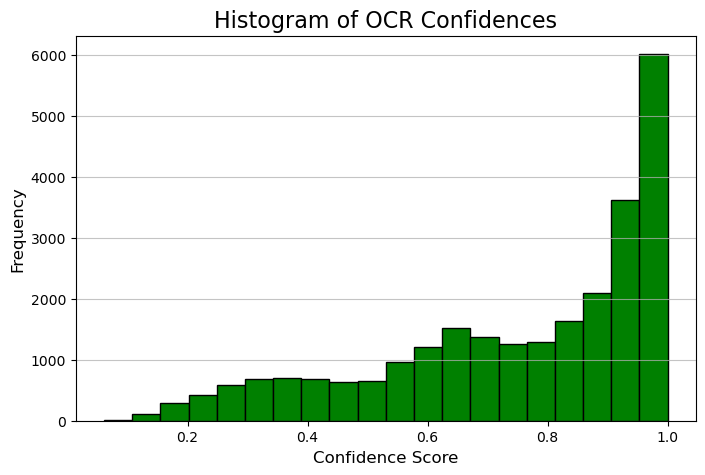

25th Percentile (Q1): 0.6069
75th Percentile (Q3): 0.9499


In [17]:
all_confidences = []

for ocr_list in data['OCR']:
    # Adding a safety check in case a row is empty or NaN
    if isinstance(ocr_list, list): 
        for item in ocr_list:
            # Check for confidence (Optional: you can use this to filter bad OCR results)
            if 'conf' in item:
                all_confidences.append(item['conf'])

# Histogram of Confidences
plt.figure(figsize=(8, 5))
plt.hist(all_confidences, bins=20, color='green', edgecolor='black')
plt.title('Histogram of OCR Confidences', fontsize=16)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# quartiles of confidence scores
Q1 = np.percentile(all_confidences, 25)
Q3 = np.percentile(all_confidences, 75)

print(f"25th Percentile (Q1): {Q1:.4f}")
print(f"75th Percentile (Q3): {Q3:.4f}")




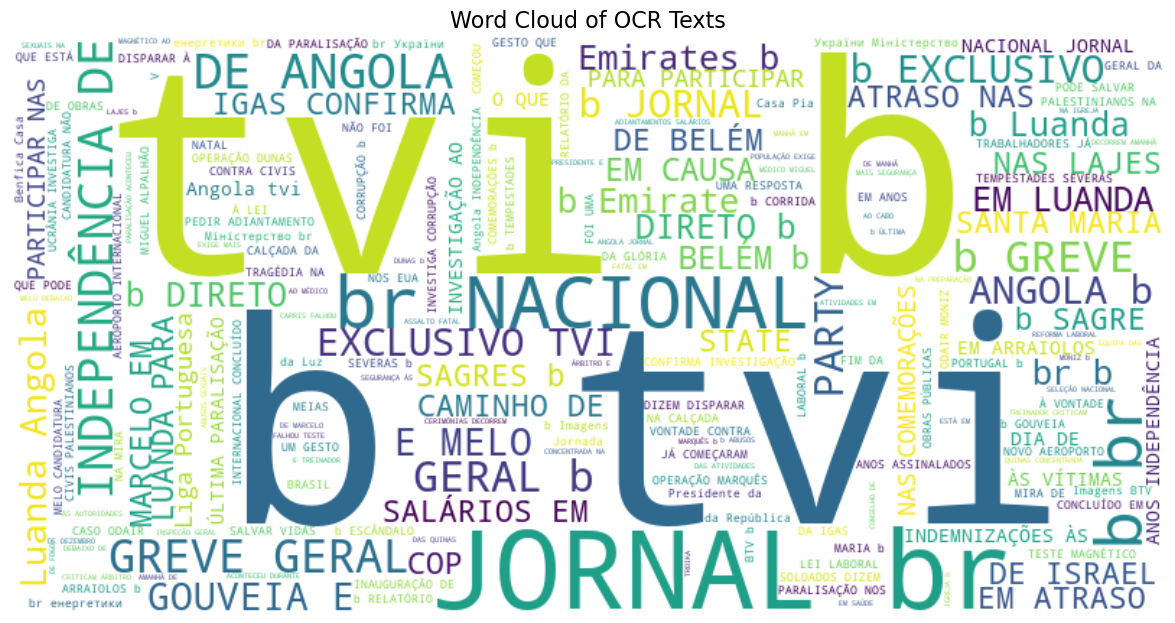

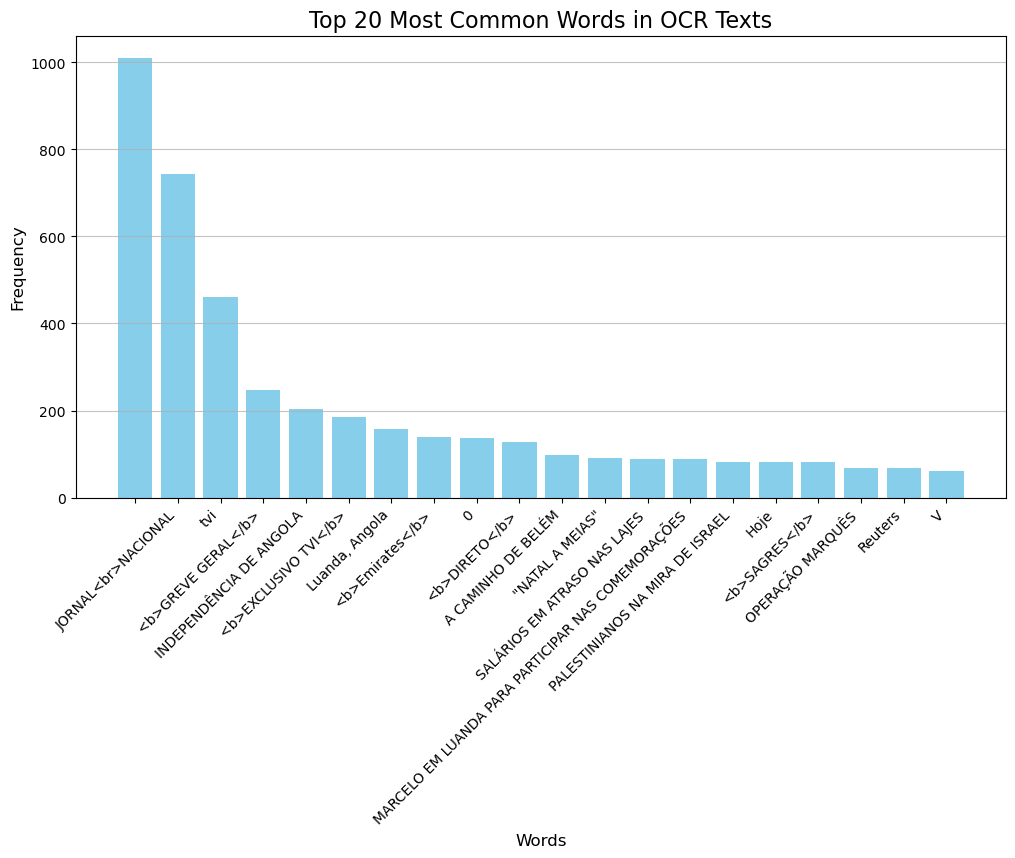

In [18]:
# plot frequency of words in OCR results
all_texts = []

for ocr_list in data['OCR']:
    if isinstance(ocr_list, list):
        for item in ocr_list:
            if 'text' in item and item['conf']>=Q1:  # Only consider texts with confidence above Q1
                all_texts.append(item['text'])



text_blob = ' '.join(all_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts', fontsize=16)
plt.show() 

# top 20 most common words in a bar chart
from collections import Counter
word_counts = Counter(all_texts)
most_common_words = word_counts.most_common(20)
words, counts = zip(*most_common_words)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.title('Top 20 Most Common Words in OCR Texts', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

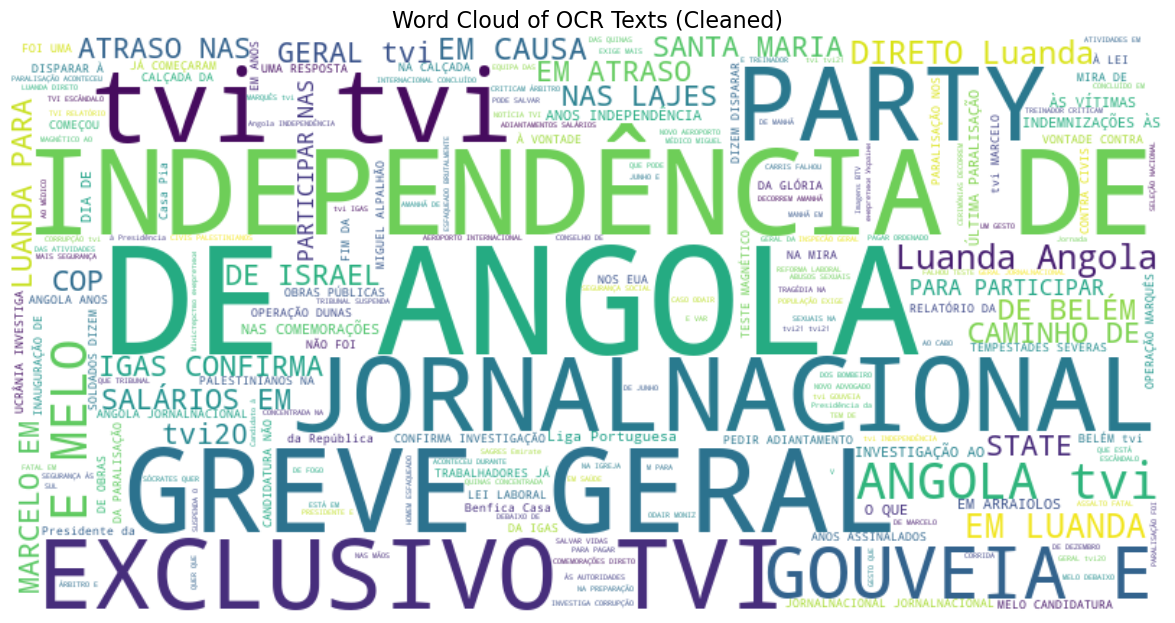

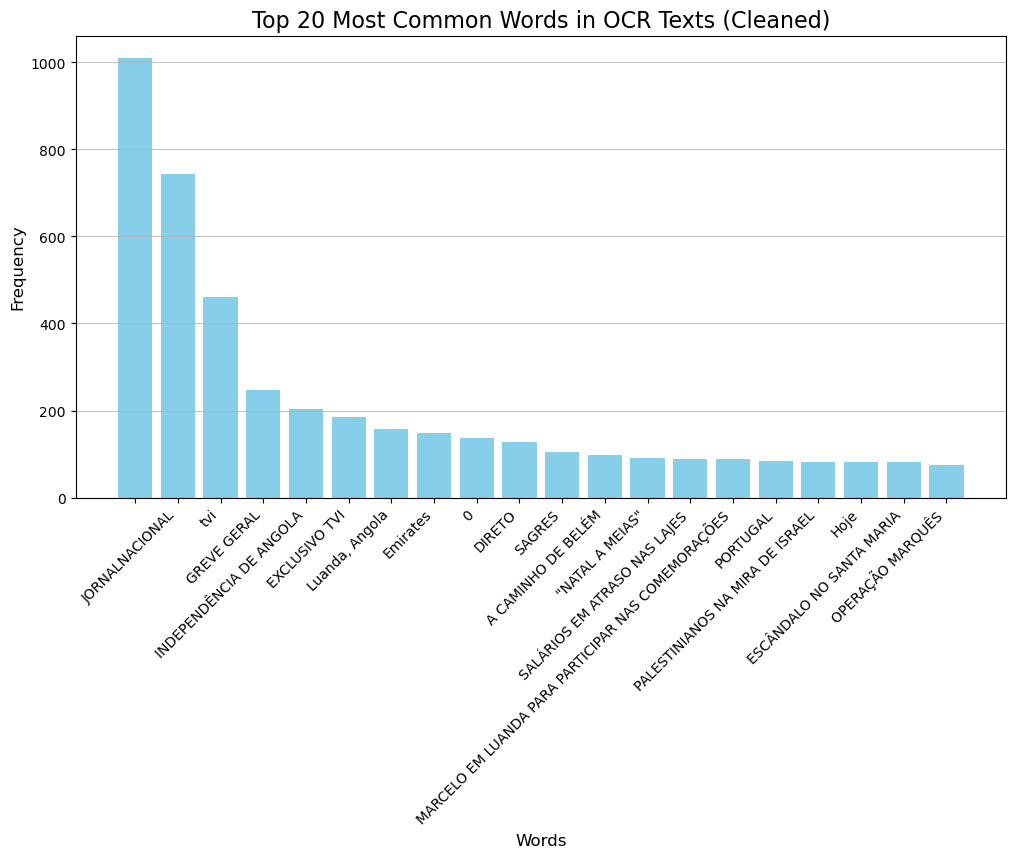

In [19]:
# how do i ignore the bold markdown in the text of the word cloud? I want to ignore the <b> and </b> tags and just count the words without them.

all_texts_cleaned = [re.sub(r'<b>|</b>|<br>', '', text) for text in all_texts]
text_blob_cleaned = ' '.join(all_texts_cleaned)
wordcloud_cleaned = WordCloud(width=800, height=400, background_color='white').generate(text_blob_cleaned)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts (Cleaned)', fontsize=16)
plt.show()

# top 20 most common words in a bar chart
from collections import Counter
import re
word_counts = Counter(all_texts_cleaned)
most_common_words = word_counts.most_common(20)
words, counts = zip(*most_common_words)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.title('Top 20 Most Common Words in OCR Texts (Cleaned)', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()


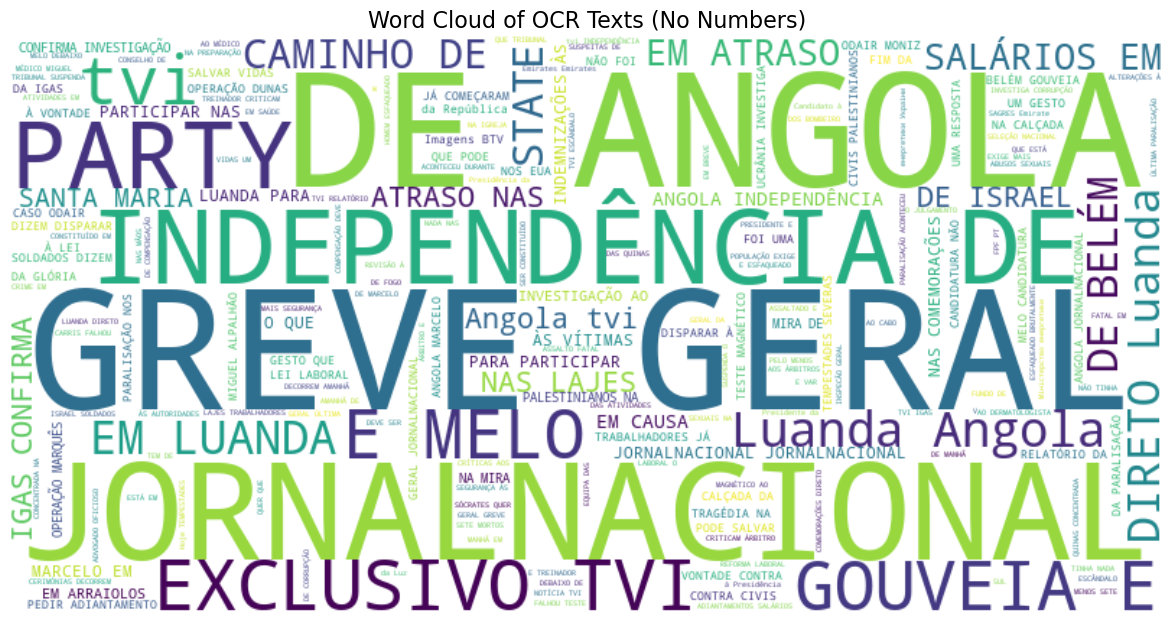

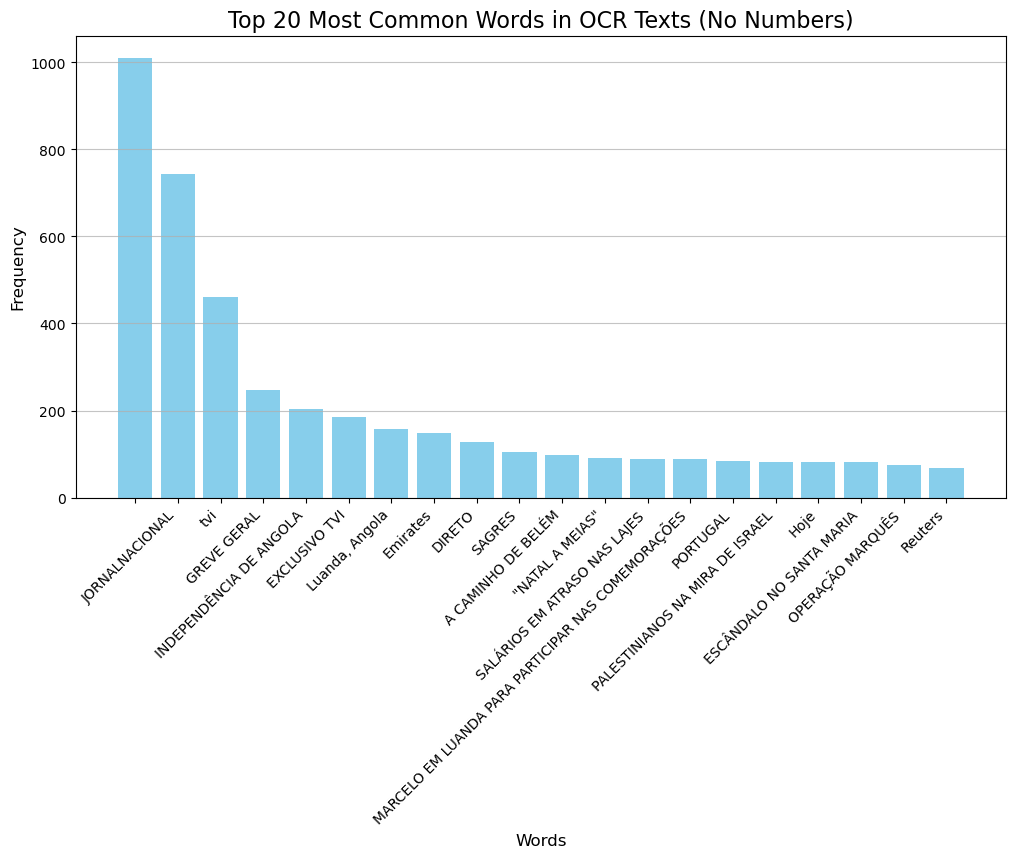

In [20]:
# can we ignore numbers in the word cloud and bar chart? Yes, we can filter out words that contain digits before generating the word cloud and bar chart. Here's how you can do it:
all_texts_no_numbers = [text for text in all_texts_cleaned if not re.search(r'\d', text)]
text_blob_no_numbers = ' '.join(all_texts_no_numbers)
wordcloud_no_numbers = WordCloud(width=800, height=400, background_color='white').generate(text_blob_no_numbers)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud_no_numbers, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts (No Numbers)', fontsize=16)
plt.show()

# top 20 most common words in a bar chart
from collections import Counter
import re
word_counts = Counter(all_texts_no_numbers)
most_common_words = word_counts.most_common(20)
words, counts = zip(*most_common_words)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.title('Top 20 Most Common Words in OCR Texts (No Numbers)', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()


Detected text:


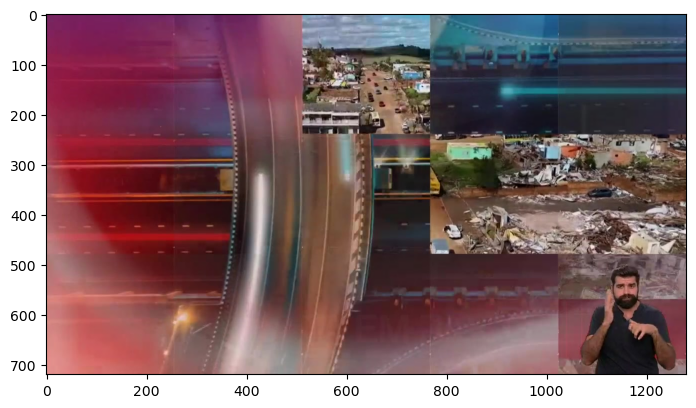

In [21]:
frame = 41

frame_id = data.iloc[frame]['Frame']
#print(frame_id)

img = Image.open(frame_id)

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.imshow(img)

print("\nDetected text:")

for t in data.iloc[frame]['OCR']:

    box = t['bbox']
    # Create a rectangle patch
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='royalblue', facecolor='none')

    # Add patch to the image
    ax.add_patch(rect)

    print(f'{t['text']}; confidence {t['conf']}')


In [22]:
# tamanho das caixas de texto